In [3]:
!pip install lime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import log_loss



df = pd.read_csv("email.csv")
df

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},01/02/2010 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},01/02/2010 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unu...
...,...,...,...,...,...,...,...,...,...,...,...
781810,{E4A7-K0YN86DN-2389ECKD},05/20/2010 11:16:27,IIW0249,PC-0843,Glass-Matthew@aol.com,Igor.I.Ward@comcast.net,NaN,Igor.I.Ward@comcast.net,30117,0,thry quoted twelve among has each towed rule d...
781811,{O4E4-V0BX75OT-8883YMAG},05/20/2010 11:16:27,MES0407,PC-8827,Herman.Ian.Abbott@dtaa.com,NaN,NaN,Minerva.Emerald.Solomon@dtaa.com,35875,0,called craftsmen build thomas damaged stored e...
781812,{U6M5-A0SA71DG-5475AXIA},05/20/2010 11:16:29,CSB0080,PC-0731,Bryar_Sweet@bellsouth.net,NaN,NaN,Catherine_Bullock@comcast.net,22351,0,hence major perpendicular peculiar synonymousl...
781813,{P1S0-W2IC21HR-6253JZFH},05/20/2010 11:16:32,CCR0863,PC-7342,Zeph_Wilkerson@yahoo.com,NaN,NaN,Charde_Rasmussen@sbcglobal.net,39317,0,late distant york normal according colonies de...


## 1. Load and Preprocess Data

In [4]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Fill missing vals
df.fillna('', inplace=True)

In [5]:
# Label encoding for categorical columns
le = LabelEncoder()
for col in ['user', 'pc', 'to', 'cc', 'bcc', 'from']:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},2010-01-02 07:11:45,588,553,57273,41257,0,1239,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},2010-01-02 07:12:16,675,665,168748,0,0,1258,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},2010-01-02 07:13:00,588,553,173967,0,0,1240,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},2010-01-02 07:13:17,588,553,119644,0,0,1240,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},2010-01-02 07:13:28,675,665,27890,0,444,1258,17319,0,this kmh october holliswood number advised unu...


## 2. Exploratory Data Analysis (EDA)

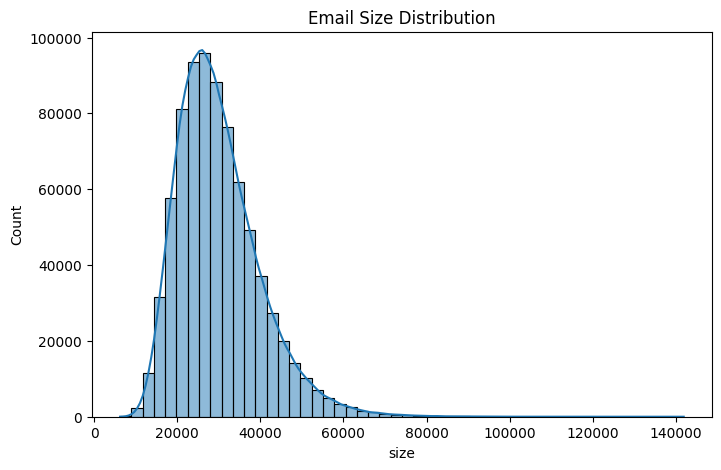

In [6]:
#size dist
plt.figure(figsize=(8,5))
sns.histplot(df['size'], bins=50, kde=True)
plt.title("Email Size Distribution")
plt.show()


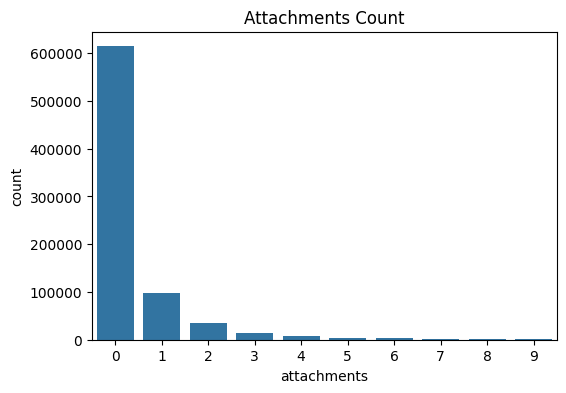

In [7]:
#Num ofattachments
plt.figure(figsize=(6,4))
sns.countplot(x='attachments', data=df)
plt.title("Attachments Count")
plt.show()


## 3. Generate Labels (Rule-Based)

In [8]:
# Feature Engineering from 'date'
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday
df['month'] = df['date'].dt.month
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

# feature selection
df.drop(columns=['date', 'to', 'cc', 'from'], inplace=True)


In [9]:
# Create a label based on 'bcc' and 'size' as suspicious
df['size'] = pd.to_numeric(df['size'], errors='coerce')
df['size'] = df['size'].fillna(0)
df['is_malicious'] = ((df['bcc'].astype(str).astype(int) > 0) & (df['size'] > 50000)).astype(int)

print(df['is_malicious'].value_counts())

is_malicious
0    776605
1      5210
Name: count, dtype: int64


In [10]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

features = df.select_dtypes(include=['number', 'bool']).columns.tolist()
features.remove('is_malicious')

X = df[features]
y = df['is_malicious']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 4. random forest Model MOHAMED TAREK 202201058

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


X = df.drop(columns=['is_malicious', 'id', 'content'])
y = df['is_malicious']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)



#eval
y_pred_rf = rf_model.predict(X_test)
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=["Benign", "Threat"]))

[[233004      0]
 [     1   1540]]
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    233004
      Threat       1.00      1.00      1.00      1541

    accuracy                           1.00    234545
   macro avg       1.00      1.00      1.00    234545
weighted avg       1.00      1.00      1.00    234545



# ***LIME***

In [21]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['Benign', 'Threat'],
    mode='classification'
)

def predict_proba_rf(x):
    return rf_model.predict_proba(x)

i =93
exp = explainer.explain_instance(
    data_row=X_test.iloc[i].values,
    predict_fn=predict_proba_rf
)
exp.show_in_notebook()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


***this LIME explanation highlights that the features 'size' and 'bcc' contributed the most to the model's prediction of a benign email in this instance. Their values pushed the probability strongly toward the benign class.***


# ***GST***

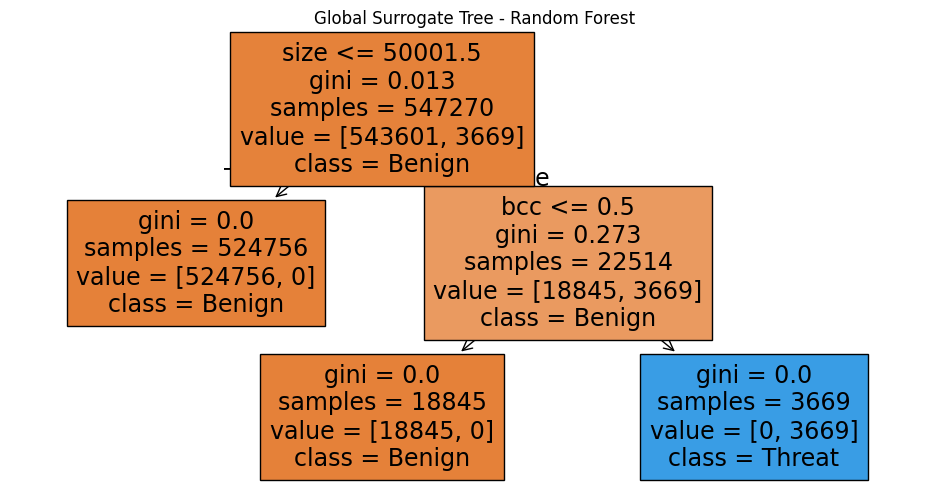

In [22]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

rf_preds_train = rf_model.predict(X_train)
surrogate_tree_rf = DecisionTreeClassifier(max_depth=3, random_state=42)
surrogate_tree_rf.fit(X_train, rf_preds_train)

plt.figure(figsize=(12,6))
plot_tree(
    surrogate_tree_rf,
    feature_names=X_train.columns,
    class_names=["Benign", "Threat"],
    filled=True
)
plt.title("Global Surrogate Tree - Random Forest")
plt.show()


***The surrogate decision tree shows that 'size' and 'bcc' are the main decision nodes used to mimic the Random Forest behavior. Emails with size > 50000 and bcc > 0 are classified as threats, aligning with the model logic.***


# ***PDP***

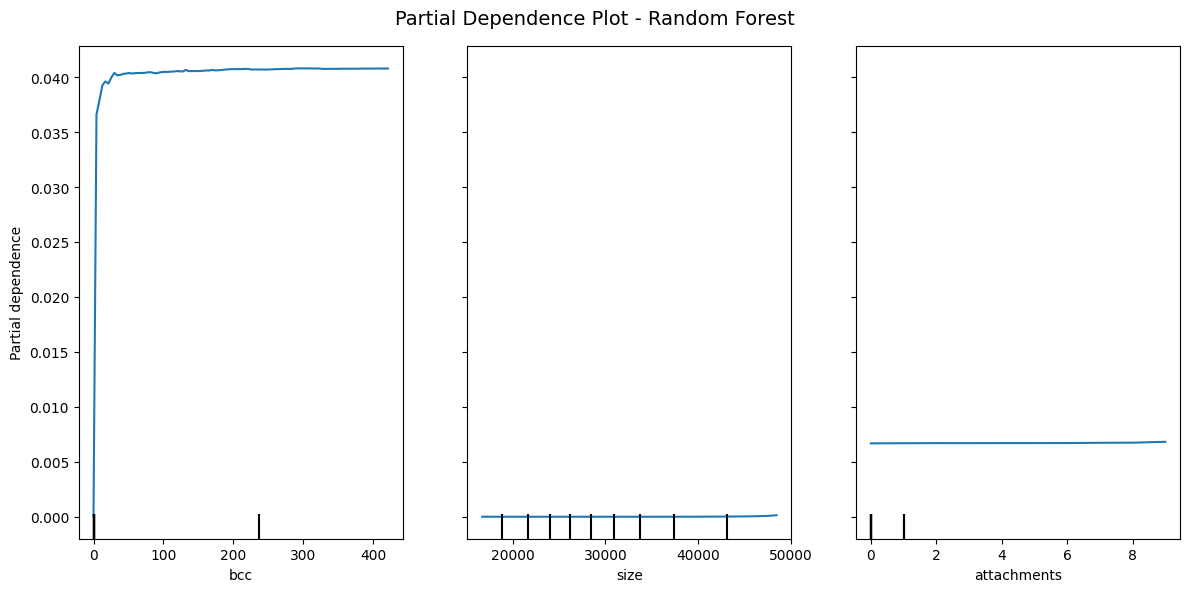

In [23]:
from sklearn.inspection import PartialDependenceDisplay

features_to_plot = ['bcc', 'size', 'attachments']

fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train,
    features=features_to_plot,
    kind='average',
    ax=ax
)
plt.suptitle("Partial Dependence Plot - Random Forest", fontsize=14)
plt.tight_layout()
plt.show()


***The PDP illustrates that increases in 'bcc' and 'size' values are associated with higher model outputs toward classifying an email as a threat. The 'attachments' feature had minimal effect on model decisions.***


# ***LOFO***

In [24]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

base_model = RandomForestClassifier(n_estimators=100, random_state=42)
base_model.fit(X_train, y_train)
base_pred = base_model.predict(X_test)
base_acc = accuracy_score(y_test, base_pred)

In [25]:
lofo_scores = {}

for col in X_train.columns:
    X_train_lofo = X_train.drop(columns=[col])
    X_test_lofo = X_test.drop(columns=[col])

    lofo_model = RandomForestClassifier(n_estimators=100, random_state=42)
    lofo_model.fit(X_train_lofo, y_train)
    lofo_pred = lofo_model.predict(X_test_lofo)
    lofo_acc = accuracy_score(y_test, lofo_pred)

    lofo_scores[col] = base_acc - lofo_acc

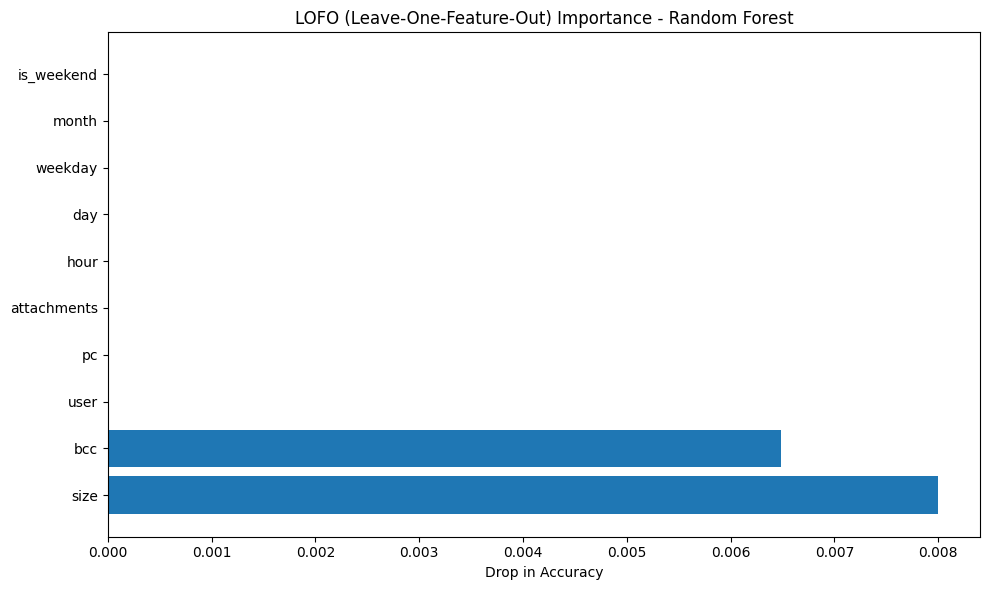

In [26]:
sorted_lofo = dict(sorted(lofo_scores.items(), key=lambda item: item[1], reverse=True))
plt.figure(figsize=(10, 6))
plt.barh(list(sorted_lofo.keys()), list(sorted_lofo.values()))
plt.title("LOFO (Leave-One-Feature-Out) Importance - Random Forest")
plt.xlabel("Drop in Accuracy")
plt.tight_layout()
plt.show()

***The LOFO analysis shows that removing 'size' or 'bcc' causes a noticeable drop in accuracy, confirming their critical role in the model’s decision-making process.***
